# Run cells from AllenDB

In [1]:
import os, sys, json
import matplotlib.pyplot as plt
import numpy as np

from allensdk.api.queries.biophysical_api import BiophysicalApi
from allensdk.model.biophys_sim.config import Config
from allensdk.model.biophysical.utils import Utils

sys.path.append("../../mods/ACT")
from act.passive import ACTPassiveModule

In [2]:
cell_name = 'PV'

work_dir = f"{cell_name}/OriginalFromAllenDB"
os.chdir(work_dir)

In [ ]:
# Compile the modfiles (make sure to update with tuned modfiles and json)
!nrnivmodl modfiles > /dev/null 2>&1

from neuron import h
h.load_file("stdrun.hoc")  # Required to use h.run()

h.nrn_load_dll("x86_64/.libs/libnrnmech.so")

--No graphics will be displayed.


1.0

## Build the cell

if you need additonal modfiles from a public repo, provide a list of the names of the modfiles and a link to the folder

In [4]:
import sys, os
from functools import wraps

def suppress_output(fn):
    @wraps(fn)
    def wrapper(*args, **kwargs):
        devnull = open(os.devnull, 'w')
        old_stdout, old_stderr = sys.stdout, sys.stderr
        sys.stdout = sys.stderr = devnull
        try:
            return fn(*args, **kwargs)
        finally:
            sys.stdout, sys.stderr = old_stdout, old_stderr
            devnull.close()
    return wrapper

**NOTE:** Control the soma area in the `build_cell` function below.

In [5]:
@suppress_output
def build_cell(soma_diam_multiplier = 1,using_hoc=False,hoc_filename=None,cell_name=None):

    if using_hoc:
      from neuron import h
      h.load_file(hoc_filename)
      return getattr(h, cell_name)()
    # Create the h object
    description = Config().load('manifest.json')
    utils = Utils(description)
    h = utils.h
    # Convert all "value" attributes to floats
    for dict in utils.description.data['genome']:
        for key, value in dict.items():
            if key == 'value': dict[key] = float(value)
    # Configure morphology
    morphology_path = description.manifest.get_path('MORPHOLOGY')
    utils.generate_morphology(morphology_path.encode('ascii', 'ignore'))
    utils.load_cell_parameters()
    # To match PP
    h.soma[0].diam = h.soma[0].diam * soma_diam_multiplier

    return h

def set_simulation(hoc_object,sim_params, soma_diam_multiplier = 1.0):
    from neuron import h
    h.load_file("stdrun.hoc")
    stim = h.IClamp(hoc_object.soma[0](0.5))
    stim.amp = sim_params['stim_amp']
    stim.delay = sim_params['stim_delay']
    stim.dur = sim_params['stim_dur']
    h.tstop = sim_params['h_tstop']
    h.dt = sim_params['h_dt']
    # h.steps_per_ms = 1 / h.dt
    return h, stim

In [6]:
def count_voltage_events(t, v):
    """
    Counts the number of times the voltage goes above -20 mV and the slope changes from positive to negative.

    Args:
        t: A NumPy array of time points.
        v: A NumPy array of voltage values.

    Returns:
        The number of events.
    """

    # Calculate the slope of the voltage
    slope = np.diff(v)

    # Find the indices where the voltage is above -20 mV
    above_threshold_indices = np.where(v[:-1] > -20)[0]

    # Find the indices where the slope changes from positive to negative
    positive_to_negative_indices = np.where((slope[:-1] > 0) & (slope[1:] < 0))[0]

    # Find the intersection of the two sets of indices
    event_indices = np.intersect1d(above_threshold_indices, positive_to_negative_indices)

    return len(event_indices)


#function to get the start and end index of the stim but in the voltage file
def get_start_end_idx(sim_params):
  start_idx = int(sim_params['stim_delay']/sim_params['h_dt'])
  end_idx = int((sim_params['stim_delay']+sim_params['stim_dur'])/sim_params['h_dt'])
  return start_idx, end_idx


#function to calculate the frequency of a voltage trace
def get_frequency(v,sim_params):

  start_idx,end_idx = get_start_end_idx(sim_params)
  spikes = count_voltage_events(np.arange(len(v.as_numpy()))[start_idx:end_idx], v.as_numpy()[start_idx:end_idx])

  if spikes> 0:
    duration_sec = sim_params['stim_dur'] / 1000.0
    freq = spikes / duration_sec
    return freq

  else:
    return 0
  

def get_rec_vars_for_i_in_sec(sec,seg):#create recording variables for every current in a section
  current_recording_vars = {}

  for mech in sec.psection()['density_mechs']:
    for param in sec.psection()['density_mechs'][mech]:
      if param[0] == 'i':#assumes only current names start with i
        attr = getattr(sec(seg),mech)
        ref = getattr(attr, f"_ref_{param}")
        current_recording_vars[f"{mech}.{param}"] = h.Vector().record(ref)

  return current_recording_vars

In [7]:

soma_diam_multiplier = 1
hobject = build_cell(soma_diam_multiplier)

# Morphology

In [8]:
print(f"Soma area: {hobject.soma[0](0.5).area()}")
print(f"Soma diam: {hobject.soma[0].diam}")
print(f"Soma L: {hobject.soma[0].L}\n")

print(f"Axon area: {hobject.axon[0](0.5).area()}")
print(f"Axon diam: {hobject.axon[0].diam}")
print(f"Axon L: {hobject.axon[0].L}")


Soma area: 669.646002883916
Soma diam: 14.599800109863281
Soma L: 14.599853515625

Axon area: 94.24777960769379
Axon diam: 1.0
Axon L: 30.0


# Passive properties

In [9]:
# Soma area from the previous cell
computed_soma_area = hobject.soma[0](0.5).area() * 1e-8 #(cm2)
# User-provided desired properties
user_provided_Rin = 195.4 * 10e6 # (to Ohm from MOhm)
user_provided_tau = 15.6 * 1e-3 # (to s from ms)
user_provided_Vrest = -65.75 # (mV)
spps = ACTPassiveModule.compute_spp(user_provided_Rin, computed_soma_area, user_provided_tau, user_provided_Vrest)
print(spps)

SettablePassiveProperties(Cm=1.192215484354815, g_bar_leak=7.642406950992403e-05, e_rev_leak=-65.75, g_bar_h=None)


### set simulation parameters

In [10]:
sim_params = {
                'stim_amp': -0.1,
                'stim_delay': 300,
                'stim_dur': 1000,
                'h_tstop': 1500,
                'h_dt': 0.025
                }


-50 pA spike frequency = 0.00 Hz
-0.035818601803342176
GettablePassiveProperties(R_in=148.5, tau1=3.5, tau2=56.3, sag_ratio=1.0, V_rest=-70.96)

-100 pA spike frequency = 0.00 Hz
-0.14287996880364062
GettablePassiveProperties(R_in=147.6, tau1=3.5, tau2=65.5, sag_ratio=0.998, V_rest=-70.96)



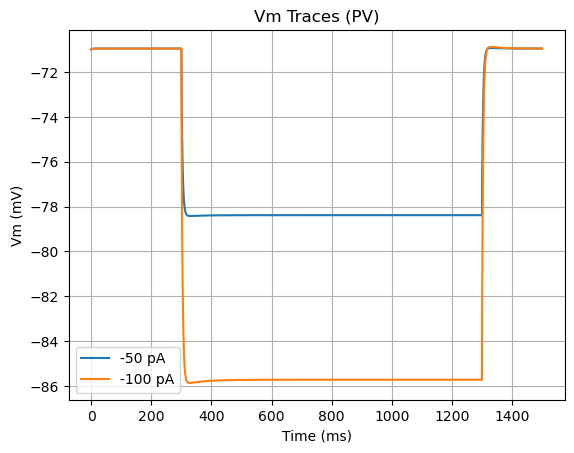

In [11]:
# Simulation parameters
sim_params = {
                'stim_amp': -0.1,
                'stim_delay': 300,
                'stim_dur': 1000,
                'h_tstop': 1500,
                'h_dt': 0.025
                }

# Currents injected for each sim
sim_amps = [-50,-100]

soma_diam_multiplier = 1

# Sim data storage
V_traces = {}
I_traces = {}
spike_freqs = {}

# Loop through and run each sim
for idx, amp_val in enumerate(sim_amps):
    # 1) set the new amp
    sim_params['stim_amp'] = amp_val / 1000.0   # convert to nA

    # 2) build & configure
    hobj = build_cell(soma_diam_multiplier)
    h, stim = set_simulation(hobj, sim_params)

    # 3) attach voltage recorder
    v = h.Vector().record(hobj.soma[0](0.5)._ref_v)
    if idx == 0:
        tvec = h.Vector().record(h._ref_t)

    # 4) attach *all* the current recorders in that section
    current_recording_vars = get_rec_vars_for_i_in_sec(hobj.soma[0], 0.5)

    # 5) run
    h.finitialize()
    h.run()

    # 6) stash numpy arrays
    T = np.array(tvec)                # Time (same for all sims)

    V = np.array(v)                   # Voltage
    V_traces[amp_val] = V

    I_traces[amp_val] = {             # Currents
        name: vec.as_numpy().copy()
        for name, vec in current_recording_vars.items()
    }
    # print(I_traces[amp_val].keys())

    # 7) Analysis
    f = get_frequency(v, sim_params)
    spike_freqs[amp_val] = f
    print(f"{amp_val} pA spike frequency = {f:.2f} Hz")

    if amp_val <0:
        # print('Desired Properties:       R_in=98.9, tau1=5.9, tau2=??.?, sag_ratio=0.960, V_rest=-71.25')
        print(f"{ACTPassiveModule.compute_gpp(v.as_numpy(), h.dt, sim_params['stim_delay'], sim_params['stim_delay']+sim_params['stim_dur']-10, sim_params['stim_amp'])}\n")
    
    # 8) Plot
    plt.plot(T, V, label=f"{amp_val} pA")
    
# Plot parameters
plt.grid(True)
plt.xlabel("Time (ms)")
# plt.xlim(250,800)
plt.ylabel("Vm (mV)")
# plt.ylim(-80,40)
plt.title(f"Vm Traces ({cell_name})")
plt.legend()
plt.show()


# Tuning Active Properties

### 1. Single Sim with Current Traces

### 2. Multi-Sim Plot

0 pA spike frequency = 0.00 Hz
10 pA spike frequency = 0.00 Hz
25 pA spike frequency = 0.00 Hz
50 pA spike frequency = 0.00 Hz
100 pA spike frequency = 0.00 Hz
150 pA spike frequency = 0.00 Hz


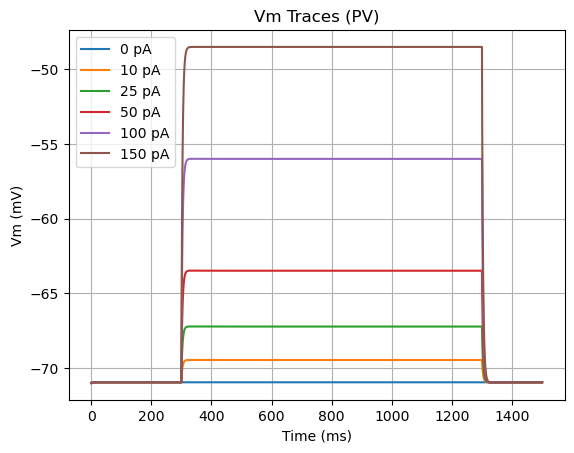

In [12]:
# Simulation parameters
sim_params = {
                'stim_amp': -0.1,
                'stim_delay': 300,
                'stim_dur': 1000,
                'h_tstop': 1500,
                'h_dt': 0.025
                }

# Currents injected for each sim
sim_amps = [0,10,25,50,100,150]

soma_diam_multiplier = 1

# Sim data storage
V_traces = {}
I_traces = {}
spike_freqs = {}

# Loop through and run each sim
for idx, amp_val in enumerate(sim_amps):
    # 1) set the new amp
    sim_params['stim_amp'] = amp_val / 1000.0   # convert to nA

    # 2) build & configure
    hobj = build_cell(soma_diam_multiplier)
    h, stim = set_simulation(hobj, sim_params)

    # 3) attach voltage recorder
    v = h.Vector().record(hobj.soma[0](0.5)._ref_v)
    if idx == 0:
        tvec = h.Vector().record(h._ref_t)

    # 4) attach *all* the current recorders in that section
    current_recording_vars = get_rec_vars_for_i_in_sec(hobj.soma[0], 0.5)

    # 5) run
    h.finitialize()
    h.run()

    # 6) stash numpy arrays
    T = np.array(tvec)                # Time (same for all sims)

    V = np.array(v)                   # Voltage
    V_traces[amp_val] = V

    I_traces[amp_val] = {             # Currents
        name: vec.as_numpy().copy()
        for name, vec in current_recording_vars.items()
    }
    # print(I_traces[amp_val].keys())

    # 7) Analysis
    f = get_frequency(v, sim_params)
    spike_freqs[amp_val] = f
    print(f"{amp_val} pA spike frequency = {f:.2f} Hz")

    if amp_val <0:
        # print('Desired Properties:       R_in=98.9, tau1=5.9, tau2=??.?, sag_ratio=0.960, V_rest=-71.25')
        print(f"{ACTPassiveModule.compute_gpp(v.as_numpy(), h.dt, sim_params['stim_delay'], sim_params['stim_delay']+sim_params['stim_dur']-10, sim_params['stim_amp'])}\n")
    
    # 8) Plot
    plt.plot(T, V, label=f"{amp_val} pA")
    
# Plot parameters
plt.grid(True)
plt.xlabel("Time (ms)")
# plt.xlim(355,365)
plt.ylabel("Vm (mV)")
# plt.ylim(-80,40)
plt.title(f"Vm Traces ({cell_name})")
plt.legend()
plt.show()


{'pas.i': Vector[2628], 'Ca_HVA.ica': Vector[2629], 'Ca_LVA.ica': Vector[2630], 'Ih.ihcn': Vector[2631], 'Im_v2.ik': Vector[2632], 'Kd.ik': Vector[2633], 'K_T.ik': Vector[2634], 'Kv2like.ik': Vector[2635], 'Kv3_1.ik': Vector[2636], 'SK.ik': Vector[2637]}


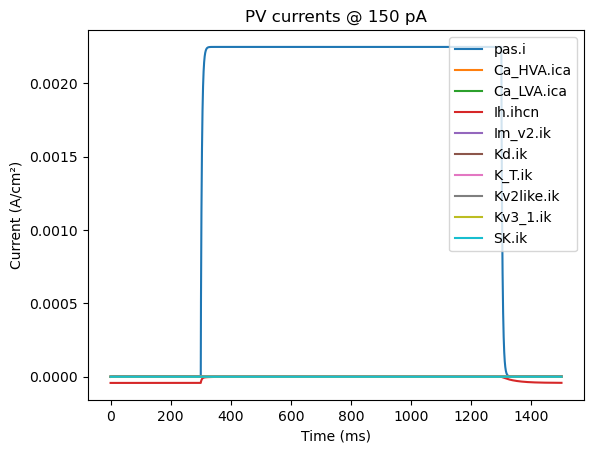

In [13]:
ampsel = sim_amps[-1]
currents_plotted = [
                    # 'pas.i', 
                    # # 'cadyn.i', 
                    # 'Ca_HVA.ica',
                    # 'Ca_LVA.ica',
                    # 'Ih.ihcn',
                    # 'Im_v2.ik', 
                    # 'Kd.ik',
                    # # 'K_T.ik',
                    # 'Kv2like.ik',
                    # 'Kv3_1.ik',
                    # 'Nap.ina',
                    # 'NaTa.ina',
                    # 'SK.ik',
                    ]
print(current_recording_vars)
plt.figure()
if currents_plotted:
    for cur in currents_plotted:
        plt.plot(T, I_traces[ampsel][cur], label=cur)
else:
    for cur_name, cur_trace in I_traces[ampsel].items():
        plt.plot(T, cur_trace, label=cur_name) 

plt.xlabel("Time (ms)")
# plt.xlim(375,485)
plt.ylabel("Current (A/cm²)")
plt.title(f"{cell_name} currents @ {ampsel} pA")
plt.legend(loc='upper right')
plt.show()

### 3. Generate FI Curve

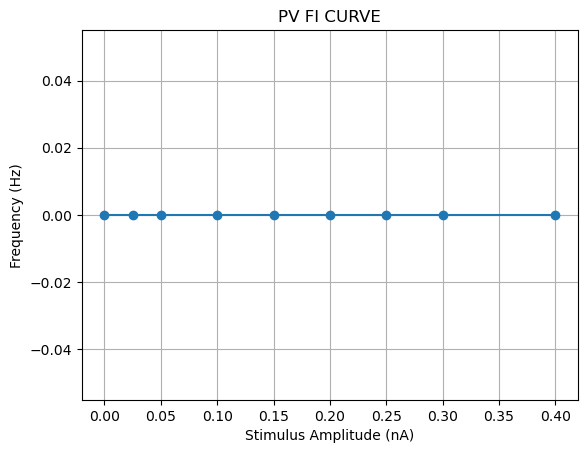

0.0: 0
0.025: 0
0.05: 0
0.1: 0
0.15: 0
0.2: 0
0.25: 0
0.3: 0
0.4: 0


In [16]:
#set simulation parameters
sim_params = {
                'stim_amp': -0.1,
                'stim_delay': 300,
                'stim_dur': 1000,
                'h_tstop': 1500,
                'h_dt': 0.025
                }

#test the cell at multiple currents to get an FI curve
freqs = []
# amps = [0.0,0.025,0.05,0.075, 0.1,0.125, 0.15,0.175, 0.2, 0.225, 0.25, 0.275, 0.3,] #-0.1, -0.075, -0.05,-0.025,  0.325,0.35,0.375,0.4, 0.425,0.45, 0.475, 0.5]
amps = [0.0,0.025,0.05, 0.1, 0.15, 0.2, 0.25,0.3,0.4]# 0.3,0.325,0.35,0.375,0.4, 0.425,0.45] #,0.475, 0.5]

soma_diam_multiplier = 6

for amp in amps:
    hobject = build_cell(soma_diam_multiplier)

    sim_params['stim_amp'] = amp
    h, stim = set_simulation(hobject,sim_params)
    v = h.Vector().record(hobject.soma[0](0.5)._ref_v)
    h.finitialize()
    h.run()
    freqs.append(get_frequency(v,sim_params))


plt.plot(amps, freqs, marker='o')
plt.title(f"{cell_name} FI CURVE")
plt.xlabel("Stimulus Amplitude (nA)")
plt.ylabel("Frequency (Hz)")
plt.grid()
plt.show()


for a, f in zip(amps, freqs):
    print(f"{a}: {f}")

13
7
13
7


ValueError: x and y must have same first dimension, but have shapes (13,) and (7,)

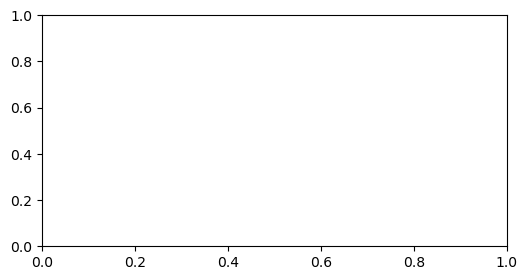

In [15]:
bio_FI_data = {
    'SST': [(00,0),(25,1),(50,5),(75,10),(100,17),(125,25),(150,32),(175,42),(200,50),(225,56),(250,60),(275,64),(300,66)],
    'PV': [(00,0),(25,0),(50,0),(75,0),(100,3),(125,7),(150,12),(175,20),(200,27),(225,35),(250,45),(275,56),(300,58)]
}
bio_FI = bio_FI_data[cell_name]
bio_amps = []
bio_freqs = []

for FI in bio_FI:
    bio_amps.append(FI[0])
    bio_freqs.append(FI[1])
print(len(bio_amps))
print(len(amps))
print(len(bio_freqs))
print(len(freqs))


plt.figure(figsize=(6,3))
plt.plot(bio_amps, freqs, marker='o', label = 'Model FI')
plt.plot(bio_amps,bio_freqs,marker = 'o', color = 'k', label = 'Bio FI' )
plt.title(f"{cell_name} FI CURVE")
plt.xlabel("Stimulus Amplitude (nA)")
plt.ylabel("Frequency (Hz)")
plt.legend()
plt.grid()
plt.show()